In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
from statsmodels.tsa.seasonal import seasonal_decompose

In [2]:
df = pd.read_csv("D:/Downloads/CO2 Concentration.xls")

In [3]:
df.head(5)

,Year,Month,CO2 Concentration
0,1975,1,330.62
1,1975,2,331.40
2,1975,3,331.87
3,1975,4,333.18
4,1975,5,333.92


In [4]:
df.shape

(144, 3)

In [5]:
df['year_month'] = df['Year'].astype(str) + '-' + df['Month'].astype(str).str.zfill(2)
df.head(5)

,Year,Month,CO2 Concentration,year_month
0,1975,1,330.62,1975-01
1,1975,2,331.40,1975-02
2,1975,3,331.87,1975-03
3,1975,4,333.18,1975-04
4,1975,5,333.92,1975-05


In [6]:
#convert to datetime format
df['year_month'] = pd.to_datetime(df['year_month'])
df = df.set_index('year_month')

In [7]:
df.head(5)

,Year,Month,CO2 Concentration
year_month,,,
1975-01-01,1975,1,330.62
1975-02-01,1975,2,331.40
1975-03-01,1975,3,331.87
1975-04-01,1975,4,333.18
1975-05-01,1975,5,333.92


In [8]:
df.drop(columns = ['Year','Month'], inplace = True)

In [9]:
df.head(5)

,CO2 Concentration
year_month,
1975-01-01,330.62
1975-02-01,331.40
1975-03-01,331.87
1975-04-01,333.18
1975-05-01,333.92


<Axes: xlabel='year_month'>

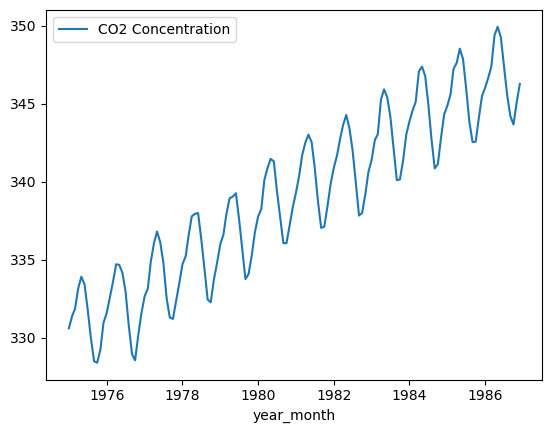

In [10]:
sns.lineplot(df)

In [11]:
#the model is additive model, because the pattern is same throughout

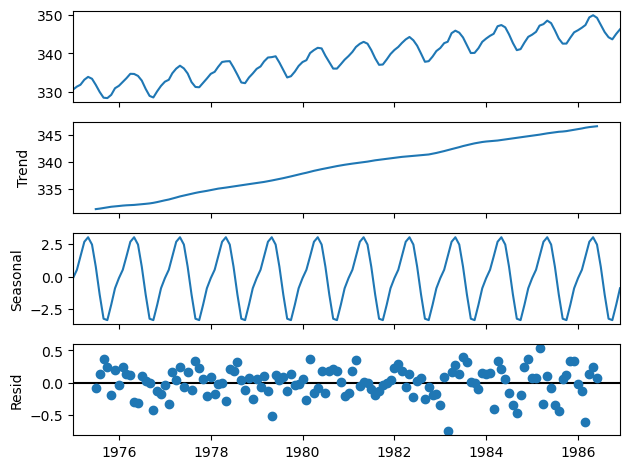

In [12]:
#decomposition of the time series - additive model
result = seasonal_decompose(df[['CO2 Concentration']], model = 'additive', period = 12)
result.plot()
plt.show()

In [13]:
import pymannkendall as mk

In [14]:
#Perform the Mann-Kendall test
#H0: There is no monotonic trend in the series

mk.original_test(df['CO2 Concentration'])

Mann_Kendall_Test(trend='increasing', h=np.True_, p=np.float64(0.0), z=np.float64(13.22737013469656), Tau=np.float64(0.7438811188811189), s=np.float64(7659.0), var_s=np.float64(335184.3333333333), slope=np.float64(0.11999999999999982), intercept=np.float64(330.545))

In [15]:
#Train test split
#Train test splitting
train_df = df[:int(df.shape[0]*0.7)]
test_df = df[int(df.shape[0]*0.7):]

In [16]:
train_df.head(5)

,CO2 Concentration
year_month,
1975-01-01,330.62
1975-02-01,331.40
1975-03-01,331.87
1975-04-01,333.18
1975-05-01,333.92


In [17]:
#single exponential smoothing model
from statsmodels.tsa.api import SimpleExpSmoothing
model = SimpleExpSmoothing(train_df)
model_single_fit = model.fit()

D:\Ananconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [18]:
forecast_single = model_single_fit.forecast(len(test_df))
print(forecast_single)

1983-05-01    345.27
1983-06-01    345.27
1983-07-01    345.27
1983-08-01    345.27
1983-09-01    345.27
1983-10-01    345.27
1983-11-01    345.27
1983-12-01    345.27
1984-01-01    345.27
1984-02-01    345.27
1984-03-01    345.27
1984-04-01    345.27
1984-05-01    345.27
1984-06-01    345.27
1984-07-01    345.27
1984-08-01    345.27
1984-09-01    345.27
1984-10-01    345.27
1984-11-01    345.27
1984-12-01    345.27
1985-01-01    345.27
1985-02-01    345.27
1985-03-01    345.27
1985-04-01    345.27
1985-05-01    345.27
1985-06-01    345.27
1985-07-01    345.27
1985-08-01    345.27
1985-09-01    345.27
1985-10-01    345.27
1985-11-01    345.27
1985-12-01    345.27
1986-01-01    345.27
1986-02-01    345.27
1986-03-01    345.27
1986-04-01    345.27
1986-05-01    345.27
1986-06-01    345.27
1986-07-01    345.27
1986-08-01    345.27
1986-09-01    345.27
1986-10-01    345.27
1986-11-01    345.27
1986-12-01    345.27
Freq: MS, dtype: float64


In [19]:
model_single_fit.params

{'smoothing_level': np.float64(0.9999999835167721),
 'smoothing_trend': np.float64(nan),
 'smoothing_seasonal': np.float64(nan),
 'damping_trend': nan,
 'initial_level': np.float64(330.62),
 'initial_trend': np.float64(nan),
 'initial_seasons': array([], dtype=float64),
 'use_boxcox': False,
 'lamda': None,
 'remove_bias': False}

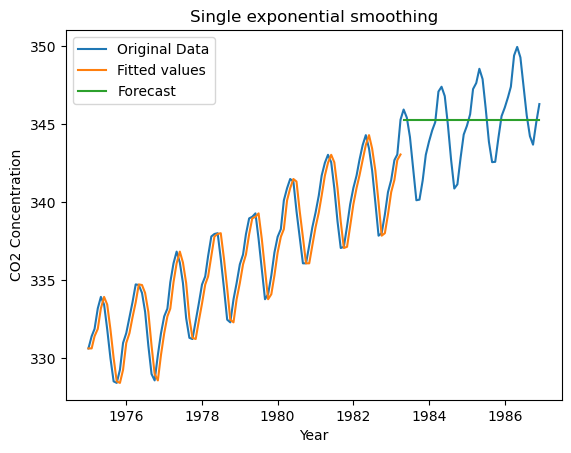

In [20]:
plt.plot(df, label ="Original Data")
plt.plot(model_single_fit.fittedvalues, label= "Fitted values")
plt.plot(forecast_single, label = "Forecast")
plt.xlabel("Year")
plt.ylabel("CO2 Concentration")
plt.title("Single exponential smoothing")
plt.legend()
plt.show()

In [21]:
#DOUBLE EXPONENETIAL SMOOTHING (Holt's model)
from statsmodels.tsa.api import Holt

In [22]:
model_double = Holt(train_df)
model_double_fit = model_double.fit()

D:\Ananconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [23]:
forecast_double = model_double_fit.forecast(len(test_df))
print(forecast_double)

1983-05-01    347.500000
1983-06-01    349.730000
1983-07-01    351.960000
1983-08-01    354.190000
1983-09-01    356.420000
1983-10-01    358.650000
1983-11-01    360.879999
1983-12-01    363.109999
1984-01-01    365.339999
1984-02-01    367.569999
1984-03-01    369.799999
1984-04-01    372.029999
1984-05-01    374.259999
1984-06-01    376.489999
1984-07-01    378.719999
1984-08-01    380.949999
1984-09-01    383.179999
1984-10-01    385.409999
1984-11-01    387.639999
1984-12-01    389.869999
1985-01-01    392.099998
1985-02-01    394.329998
1985-03-01    396.559998
1985-04-01    398.789998
1985-05-01    401.019998
1985-06-01    403.249998
1985-07-01    405.479998
1985-08-01    407.709998
1985-09-01    409.939998
1985-10-01    412.169998
1985-11-01    414.399998
1985-12-01    416.629998
1986-01-01    418.859998
1986-02-01    421.089998
1986-03-01    423.319997
1986-04-01    425.549997
1986-05-01    427.779997
1986-06-01    430.009997
1986-07-01    432.239997
1986-08-01    434.469997


In [24]:
model_double_fit.params

{'smoothing_level': np.float64(0.9999999846296241),
 'smoothing_trend': np.float64(0.9999999844654746),
 'smoothing_seasonal': np.float64(nan),
 'damping_trend': nan,
 'initial_level': np.float64(330.62),
 'initial_trend': np.float64(0.7799999999999727),
 'initial_seasons': array([], dtype=float64),
 'use_boxcox': False,
 'lamda': None,
 'remove_bias': False}

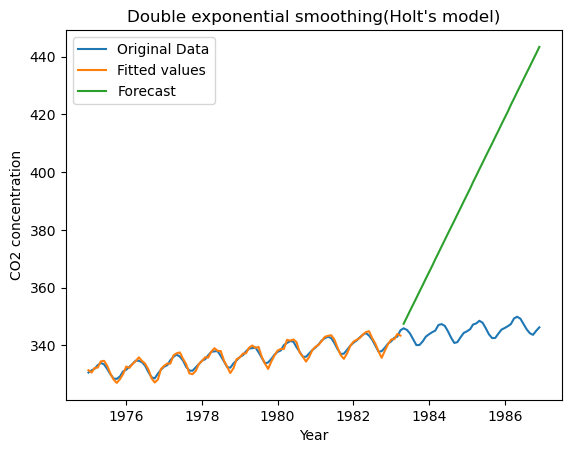

In [25]:
plt.plot(df, label ="Original Data")
plt.plot(model_double_fit.fittedvalues, label= "Fitted values")
plt.plot(forecast_double, label = "Forecast")
plt.xlabel("Year")
plt.ylabel("CO2 concentration")
plt.title("Double exponential smoothing(Holt's model)")
plt.legend()
plt.show()

In [26]:
#TRIPLE EXPONENTIAL SMOOTHING (HOLT_WINTER'S MODEL)
from statsmodels.tsa.api import ExponentialSmoothing

In [27]:
model_triple = ExponentialSmoothing(train_df, seasonal_periods = 12, trend = "add", seasonal = "add") #from the pegel's chart, since it looks similar to the additive-addititve model, therefore both trend and seasonality have been taken as additive
model_triple_fit = model_triple.fit()

D:\Ananconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [28]:
model_triple_fit.params

{'smoothing_level': np.float64(0.45915108508784663),
 'smoothing_trend': np.float64(0.0),
 'smoothing_seasonal': np.float64(0.0),
 'damping_trend': nan,
 'initial_level': np.float64(330.48493969182323),
 'initial_trend': np.float64(0.11765487502248166),
 'initial_seasons': array([-0.13509468,  0.5339116 ,  1.55178703,  2.62523818,  2.88839971,
         2.40441526,  0.7468054 , -1.36589194, -3.23346509, -3.37620923,
        -2.2488025 , -1.02646765]),
 'use_boxcox': False,
 'lamda': None,
 'remove_bias': False}

In [29]:
forecast_triple = model_triple_fit.forecast(len(test_df))
print(forecast_triple)

1983-05-01    345.256590
1983-06-01    344.890260
1983-07-01    343.350305
1983-08-01    341.355263
1983-09-01    339.605345
1983-10-01    339.580255
1983-11-01    340.825317
1983-12-01    342.165307
1984-01-01    343.174334
1984-02-01    343.960996
1984-03-01    345.096526
1984-04-01    346.287632
1984-05-01    346.668448
1984-06-01    346.302119
1984-07-01    344.762164
1984-08-01    342.767121
1984-09-01    341.017203
1984-10-01    340.992114
1984-11-01    342.237175
1984-12-01    343.577165
1985-01-01    344.586193
1985-02-01    345.372854
1985-03-01    346.508384
1985-04-01    347.699490
1985-05-01    348.080307
1985-06-01    347.713977
1985-07-01    346.174022
1985-08-01    344.178980
1985-09-01    342.429062
1985-10-01    342.403972
1985-11-01    343.649034
1985-12-01    344.989024
1986-01-01    345.998051
1986-02-01    346.784713
1986-03-01    347.920243
1986-04-01    349.111349
1986-05-01    349.492165
1986-06-01    349.125836
1986-07-01    347.585881
1986-08-01    345.590838


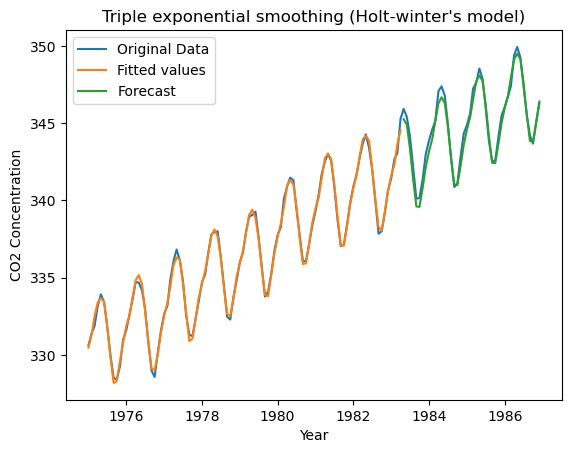

In [30]:
plt.plot(df, label ="Original Data")
plt.plot(model_triple_fit.fittedvalues, label= "Fitted values")
plt.plot(forecast_triple, label = "Forecast")
plt.xlabel("Year")
plt.ylabel("CO2 Concentration")
plt.title("Triple exponential smoothing (Holt-winter's model)")
plt.legend()
plt.show()

In [31]:
#using add-multi model
model_triple_mul = ExponentialSmoothing(train_df, seasonal_periods = 12, trend = "add", seasonal = "mul")

model_triple_fit_mul = model_triple_mul.fit()

D:\Ananconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [32]:
forecast_triple_mul = model_triple_fit_mul.forecast(len(test_df))
print(forecast_triple_mul)

1983-05-01    345.278666
1983-06-01    344.903113
1983-07-01    343.331240
1983-08-01    341.297056
1983-09-01    339.510695
1983-10-01    339.484586
1983-11-01    340.750814
1983-12-01    342.113280
1984-01-01    343.137473
1984-02-01    343.939359
1984-03-01    345.095547
1984-04-01    346.309642
1984-05-01    346.698059
1984-06-01    346.320476
1984-07-01    344.741661
1984-08-01    342.698640
1984-09-01    340.904466
1984-10-01    340.877774
1984-11-01    342.148720
1984-12-01    343.516296
1985-01-01    344.544208
1985-02-01    345.348900
1985-03-01    346.509344
1985-04-01    347.727928
1985-05-01    348.117451
1985-06-01    347.737839
1985-07-01    346.152081
1985-08-01    344.100225
1985-09-01    342.298238
1985-10-01    342.270961
1985-11-01    343.546626
1985-12-01    344.919312
1986-01-01    345.950943
1986-02-01    346.758441
1986-03-01    347.923140
1986-04-01    349.146214
1986-05-01    349.536844
1986-06-01    349.155203
1986-07-01    347.562502
1986-08-01    345.501809


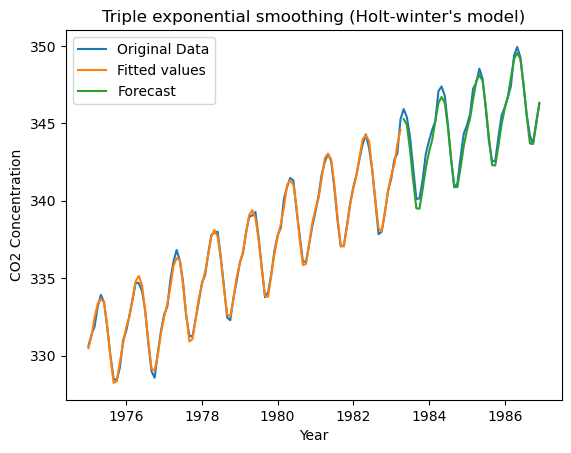

In [33]:
plt.plot(df, label ="Original Data")
plt.plot(model_triple_fit_mul.fittedvalues, label= "Fitted values")
plt.plot(forecast_triple_mul, label = "Forecast")
plt.xlabel("Year")
plt.ylabel("CO2 Concentration")
plt.title("Triple exponential smoothing (Holt-winter's model)")
plt.legend()
plt.show()

In [34]:
#testing for the accuracy of the two models
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

In [35]:
mape_test_add = mean_absolute_percentage_error(test_df['CO2 Concentration'], forecast_triple)
print("MAPE Test for Test Data:",mape_test_add)

MAPE Test for Test Data: 0.0010865825015769282


In [36]:
mape_test_mul = mean_absolute_percentage_error(test_df['CO2 Concentration'], forecast_triple)
print("MAPE Test for Test Data:",mape_test_mul)

MAPE Test for Test Data: 0.0010865825015769282


In [37]:
#No difference in both methodologies

In [38]:
#ADF Test
#H0: Series is not stationary, ie,e series has a unit root
#H1: Series is stationary, ie,e series has no unit root

In [39]:
from statsmodels.tsa.stattools import adfuller 
result = adfuller(df)

print("ADF Statistic:", result[0])
print("p-value:",result[1])

ADF Statistic: -0.612294140001058
p-value: 0.8681797862771403


In [ ]:
#p-value > 0.05 : fail to reject to H0, i.e, series is not stationary

In [ ]:
#KPSS Test
#H0: Series is trend stationary, ie,e series has no unit root
#H1: Series is non-stationary, ie,e series has a unit root

##It is very specific to trend (KPSS)

In [40]:
from statsmodels.tsa.stattools import kpss
kp = kpss(df)
p = kp[1]

print("p-value for KPSS Test(untransformed) = ",p)

p-value for KPSS Test(untransformed) =  0.01


C:\Users\Dell\AppData\Local\Temp\ipykernel_5200\3171673279.py:2: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kp = kpss(df)
